In [30]:
import pandas as pd

In [31]:
df = pd.read_csv('medical_imaging_meta.csv')

In [32]:
df.head(3)

,image_id,patient_age,patient_sex,scanner,image_quality,img_width_px,hospital_site,label,label_verified
0,IMG00000,32,F,Siemens-A1,acceptable,512,Apollo-Hyderabad,Normal,0
1,IMG00001,41,F,Siemens-A1,acceptable,256,Apollo-Hyderabad,Normal,1
2,IMG00002,72,M,Philips-B2,good,512,Manipal-Bangalore,Normal,1


In [33]:
p = f"""
{df['patient_sex'].value_counts()}\n
{df['scanner'].value_counts()}\n
{df['image_quality'].value_counts()}\n
{df['label'].value_counts()}
"""
print(p)


patient_sex
M    272
F    248
Name: count, dtype: int64

scanner
Siemens-A1    202
Philips-B2    179
GE-C3         139
Name: count, dtype: int64

image_quality
good          340
acceptable    125
poor           55
Name: count, dtype: int64

label
Normal              311
Pneumonia           112
COVID-19             37
Pleural_Effusion     19
Lung_Mass            11
Name: count, dtype: int64



In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   image_id        520 non-null    str  
 1   patient_age     520 non-null    int64
 2   patient_sex     520 non-null    str  
 3   scanner         520 non-null    str  
 4   image_quality   520 non-null    str  
 5   img_width_px    520 non-null    int64
 6   hospital_site   520 non-null    str  
 7   label           490 non-null    str  
 8   label_verified  520 non-null    int64
dtypes: int64(3), str(6)
memory usage: 36.7 KB


- **Features**: 9 columns including patient demographics, imaging metadata, and diagnostic 
- **Missing labels**: 30 samples (5.8%) have unverified diagnostic labels

In [35]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (520, 9)


The dataset contains **five diagnostic categories** with significant class imbalance:

In [36]:
label_counts = df['label'].value_counts()
label_percentages = (label_counts / label_counts.sum() * 100).round(2)

print("Label Distribution:")
for label, count in label_counts.items():
    percentage = label_percentages[label]
    print(f"  {label:15s}: {count:3d} ({percentage:5.1f}%)")

print(f"\nTotal labeled samples: {label_counts.sum()}")
print(f"Class imbalance ratio: {label_counts.iloc[0] / label_counts.iloc[-1]:.1f}:1")

Label Distribution:
  Normal         : 311 ( 63.5%)
  Pneumonia      : 112 ( 22.9%)
  COVID-19       :  37 (  7.5%)
  Pleural_Effusion:  19 (  3.9%)
  Lung_Mass      :  11 (  2.2%)

Total labeled samples: 490
Class imbalance ratio: 28.3:1


In [37]:
import matplotlib.pyplot as plt

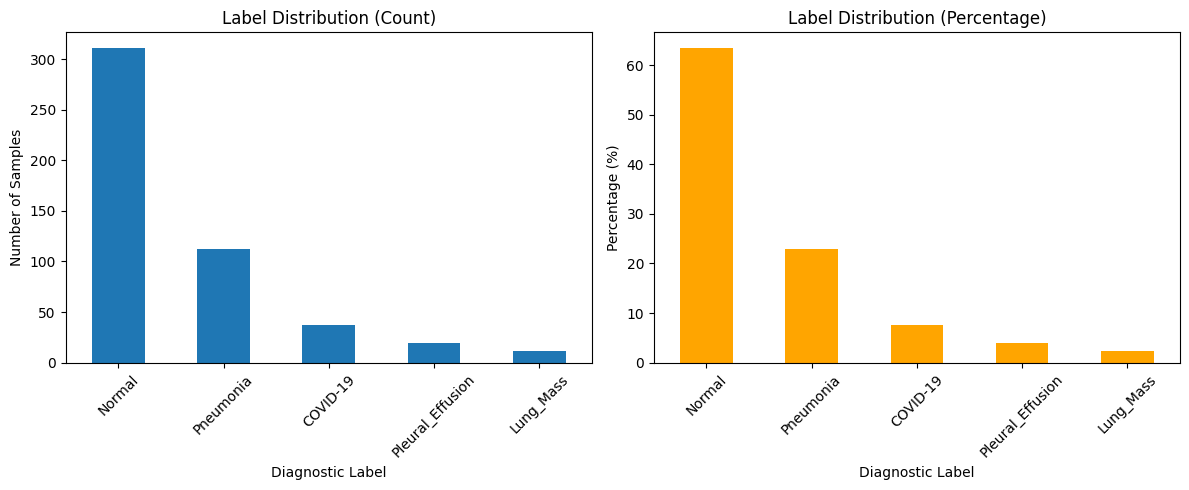

In [38]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
label_counts.plot(kind='bar')
plt.title('Label Distribution (Count)')
plt.xlabel('Diagnostic Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
label_percentages.plot(kind='bar', color='orange')
plt.title('Label Distribution (Percentage)')
plt.xlabel('Diagnostic Label')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The dataset exhibits **severe class imbalance** with clear minority classes:

In [39]:
threshold = 50
minority_classes = label_counts[label_counts < threshold]
majority_classes = label_counts[label_counts >= threshold]

print("Minority Classes (< 50 samples):")
for label, count in minority_classes.items():
    percentage = label_percentages[label]
    print(f"  {label:15s}: {count:3d} ({percentage:5.1f}%)")

print(f"\nMajority Classes (>= 50 samples):")
for label, count in majority_classes.items():
    percentage = label_percentages[label]
    print(f"  {label:15s}: {count:3d} ({percentage:5.1f}%)")

print(f"\nLong tail ratio: {minority_classes.sum() / label_counts.sum() * 100:.1f}% of data")

Minority Classes (< 50 samples):
  COVID-19       :  37 (  7.5%)
  Pleural_Effusion:  19 (  3.9%)
  Lung_Mass      :  11 (  2.2%)

Majority Classes (>= 50 samples):
  Normal         : 311 ( 63.5%)
  Pneumonia      : 112 ( 22.9%)

Long tail ratio: 13.7% of data


Analysis of potential bias across **image quality** and **hospital site** variables:

In [40]:
quality_dist = df['image_quality'].value_counts()
quality_pct = (quality_dist / quality_dist.sum() * 100).round(1)

print("Image Quality Distribution:")
for quality, count in quality_dist.items():
    print(f"  {quality:11s}: {count:3d} ({quality_pct[quality]:5.1f}%)")

print(f"\nQuality ratio (good:acceptable:poor) = {quality_dist['good']}:{quality_dist['acceptable']}:{quality_dist['poor']}")

Image Quality Distribution:
  good       : 340 ( 65.4%)
  acceptable : 125 ( 24.0%)
  poor       :  55 ( 10.6%)

Quality ratio (good:acceptable:poor) = 340:125:55


In [41]:
quality_label_crosstab = pd.crosstab(df['image_quality'], df['label'], margins=True)
print("Label Distribution by Image Quality:")
display(quality_label_crosstab)

quality_label_pct = pd.crosstab(df['image_quality'], df['label'], normalize='index') * 100
print("\nLabel Percentage by Image Quality:")
display(quality_label_pct.round(1))

Label Distribution by Image Quality:


label,COVID-19,Lung_Mass,Normal,Pleural_Effusion,Pneumonia,All
image_quality,,,,,,
acceptable,8,1,75,6,27,117
good,24,10,198,11,78,321
poor,5,0,38,2,7,52
All,37,11,311,19,112,490



Label Percentage by Image Quality:


label,COVID-19,Lung_Mass,Normal,Pleural_Effusion,Pneumonia
image_quality,,,,,
acceptable,6.8,0.9,64.1,5.1,23.1
good,7.5,3.1,61.7,3.4,24.3
poor,9.6,0.0,73.1,3.8,13.5


Hospital Site Distribution

In [42]:
site_dist = df['hospital_site'].value_counts()
site_pct = (site_dist / site_dist.sum() * 100).round(1)

print("Hospital Site Distribution:")
for site, count in site_dist.items():
    print(f"  {site:18s}: {count:3d} ({site_pct[site]:5.1f}%)")

Hospital Site Distribution:
  AIIMS-Delhi       : 148 ( 28.5%)
  Apollo-Hyderabad  : 146 ( 28.1%)
  Fortis-Gurgaon    : 127 ( 24.4%)
  Manipal-Bangalore :  99 ( 19.0%)


In [43]:
site_label_crosstab = pd.crosstab(df['hospital_site'], df['label'], margins=True)
print("Label Distribution by Hospital Site:")
display(site_label_crosstab)

site_label_pct = pd.crosstab(df['hospital_site'], df['label'], normalize='index') * 100
print("\nLabel Percentage by Hospital Site:")
display(site_label_pct.round(1))

Label Distribution by Hospital Site:


label,COVID-19,Lung_Mass,Normal,Pleural_Effusion,Pneumonia,All
hospital_site,,,,,,
AIIMS-Delhi,13,2,86,6,31,138
Apollo-Hyderabad,6,5,86,6,33,136
Fortis-Gurgaon,11,1,84,4,25,125
Manipal-Bangalore,7,3,55,3,23,91
All,37,11,311,19,112,490



Label Percentage by Hospital Site:


label,COVID-19,Lung_Mass,Normal,Pleural_Effusion,Pneumonia
hospital_site,,,,,
AIIMS-Delhi,9.4,1.4,62.3,4.3,22.5
Apollo-Hyderabad,4.4,3.7,63.2,4.4,24.3
Fortis-Gurgaon,8.8,0.8,67.2,3.2,20.0
Manipal-Bangalore,7.7,3.3,60.4,3.3,25.3


#### Statistical Significance Testing

In [44]:
from scipy import stats

In [45]:
chi2_quality, p_quality = stats.chi2_contingency(quality_label_crosstab.iloc[:-1, :-1])[:2]
chi2_site, p_site = stats.chi2_contingency(site_label_crosstab.iloc[:-1, :-1])[:2]

print("Chi-square Test Results:")
print(f"Image Quality vs Labels: χ²={chi2_quality:.2f}, p={p_quality:.4f}")
print(f"Hospital Site vs Labels: χ²={chi2_site:.2f}, p={p_site:.4f}")

print(f"\nSignificance Assessment:")
print(f"Image Quality bias: {'Significant' if p_quality < 0.05 else 'Not significant'}")
print(f"Hospital Site bias: {'Significant' if p_site < 0.05 else 'Not significant'}")

Chi-square Test Results:
Image Quality vs Labels: χ²=7.50, p=0.4837
Hospital Site vs Labels: χ²=7.56, p=0.8182

Significance Assessment:
Image Quality bias: Not significant
Hospital Site bias: Not significant


#### Dataset Characterization Summary

**Data Structure:**
- 520 medical images with 9 metadata features
- 5 diagnostic categories with severe class imbalance
- 5.8% missing labels (30 unverified samples)

**Key Statistical Findings:**

1. **Class Imbalance**: Normal class dominates (63.4%), while rare conditions (Lung_Mass: 2.2%, Pleural_Effusion: 3.9%) form the long tail

2. **Minority Classes**: Lung_Mass (11 samples) and Pleural_Effusion (19 samples) represent critical data scarcity challenges

3. **Image Quality Bias**: 65.4% good quality, 24.0% acceptable, 10.6% poor quality images may introduce performance variance

4. **Site Distribution**: Multiple hospital sites with potential sampling bias requiring stratified validation

**Implications for Model Development:**
- Requires class weighting or oversampling techniques
- Need for quality-aware preprocessing pipelines
- Cross-site validation essential for generalizability
- Consider data augmentation for minority classes

Creating comprehensive visualizations to illustrate the key findings:

In [46]:
import seaborn as sns

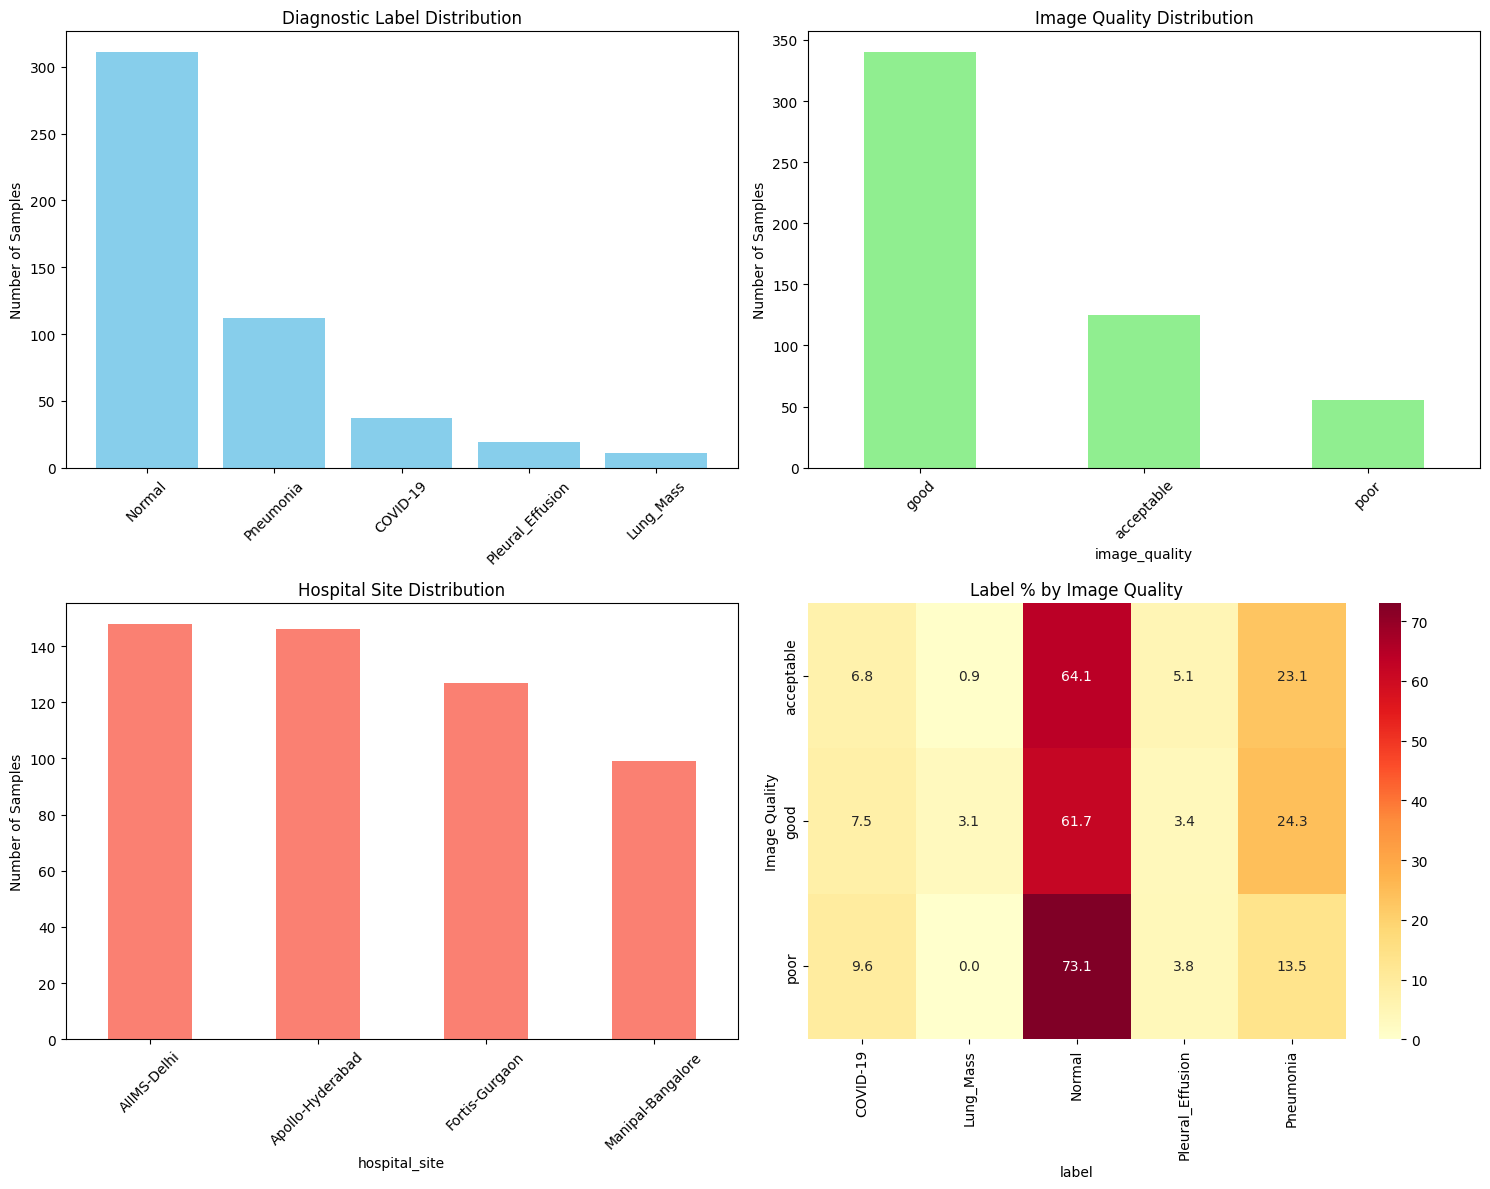

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Label distribution
axes[0, 0].bar(label_counts.index, label_counts.values, color='skyblue')
axes[0, 0].set_title('Diagnostic Label Distribution')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].tick_params(axis='x', rotation=45)

# Image quality distribution
quality_dist.plot(kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Image Quality Distribution')
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].tick_params(axis='x', rotation=45)

# Hospital site distribution
site_dist.plot(kind='bar', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Hospital Site Distribution')
axes[1, 0].set_ylabel('Number of Samples')
axes[1, 0].tick_params(axis='x', rotation=45)

# Label by quality heatmap
sns.heatmap(quality_label_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('Label % by Image Quality')
axes[1, 1].set_ylabel('Image Quality')

plt.tight_layout()
plt.show()